In [1]:
import pandas as pd
import  matplotlib.pyplot as plt

# Task1.1: Load and inspect data

Load the dataset and display the first 10 rows.
Understand the basic structure of the data, including data types and missing values.


In [2]:
data = pd.read_csv("Railway_info.csv")

In [3]:
data.head(10)

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
5,421,LKO-SVDK FTR,LUCKNOW JN.,SHRI MATA VAISHNO DEVI KATRA,Tuesday
6,422,SVDK-LKO FTR,SHRI MATA VAISHNO DEVI KATRA,LUCKNOW JN.,Monday
7,477,FTR TRAIN NO,SIRSA,SIRSA,Sunday
8,502,RJPB-UMB FTR,RAJENDRANAGAR TERMINAL,AMBALA CANTT JN,Monday
9,504,PNBE-BTI FTR,PATNA JN.,BATHINDA JN,Wednesday


In [4]:
data.info()
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Train_No                  11113 non-null  int64 
 1   Train_Name                11113 non-null  object
 2   Source_Station_Name       11113 non-null  object
 3   Destination_Station_Name  11113 non-null  object
 4   days                      11113 non-null  object
dtypes: int64(1), object(4)
memory usage: 434.2+ KB
Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64


# Task 1.2: Basic Statistics

Calculate basic statistics such as the number of trains, unique source stations, and unique destination stations.
Find the most common source and destination stations


In [5]:
print("Total no of trains:",data["Train_No"].count())
print("unique source stations",data["Source_Station_Name"].nunique())
print("unique destination stations" , data["Destination_Station_Name"].nunique())

Total no of trains: 11113
unique source stations 921
unique destination stations 924


In [6]:
#most common source and destinations
print(data["Source_Station_Name"].value_counts().head(1))
print(data["Destination_Station_Name"].value_counts().head(1))

Source_Station_Name
CST-MUMBAI    513
Name: count, dtype: int64
Destination_Station_Name
CST-MUMBAI    514
Name: count, dtype: int64



# Task 1.3: Data Cleaning


Identify and handle missing values in the dataset.
Standardize the format of station names (e.g., make all names uppercase).


In [7]:
data["Source_Station_Name"] = data["Source_Station_Name"].str.upper()
data["Destination_Station_Name"] = data["Destination_Station_Name"].str.upper()

data.fillna("UNKNOWN", inplace=True)

In [8]:
data.head()

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday


In [9]:
print(data.isnull().sum())

Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64


In [10]:
print(data["Train_Name"].value_counts())
data["Train_Name"].count()

Train_Name
TBM-MSB EMU     139
MSB-TBM EMU     137
PASS             74
VLCY-MSBEMUL     70
CGL-MSB EMU      65
               ... 
MYS - HWH SF      1
HWH-MYS SF E      1
ERS - BSP SF      1
BSP - ERS SF      1
RE-MTC PASSE      1
Name: count, Length: 7580, dtype: int64


np.int64(11113)

### so Total no of train are 11,113

# level -2

## Task 2.1: Data Filtering

Filter the data to show trains that operate on specific days (e.g., only on Saturdays).
Extract and create a new dataframe for trains that start from a specific station.


In [11]:
sat_trains = data[data["days"] == "Saturday"]
print(sat_trains.head())

    Train_No    Train_Name Source_Station_Name Destination_Station_Name  \
0        107  SWV-MAO-VLNK     SAWANTWADI ROAD              MADGOAN JN.   
4        401  BSB BHARATDA          AURANGABAD             VARANASI JN.   
21      1196  NGP-KRMI SPL      NAGPUR JN.(CR)                  KARMALI   
28      1706   JBP-BDTS SF            JABALPUR          BANDRA TERMINUS   
45      2834  SRC-RJT SF A     SANTRAGACHI JN.                   RAJKOT   

        days  
0   Saturday  
4   Saturday  
21  Saturday  
28  Saturday  
45  Saturday  


In [12]:
data["days"] = data["days"].str.replace(r"d$", "", regex=True)   # this step is to ignore duplicate days 
# we use regex to specify where d should be removed 

In [13]:
print(data["days"].unique())

['Saturday' 'Friday' 'Wednesday' 'Tuesday' 'Monday' 'Sunday' 'Thursday']


In [14]:
data["days"].value_counts()

days
Friday       1649
Tuesday      1628
Wednesday    1612
Sunday       1602
Saturday     1593
Thursday     1526
Monday       1503
Name: count, dtype: int64

In [15]:
aur_trains = data[data["Source_Station_Name"] == "AURANGABAD"]
aur_trains

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
204,7505,AWB-QLN,AURANGABAD,QUILON,Wednesday
2268,17619,AWB-NED WEEK,AURANGABAD,NANDED,Sunday
2270,17621,AWB-RU EXP,AURANGABAD,RENIGUNTA JN.,Saturday
7303,57550,AWB-HYB PASS,AURANGABAD,HYDERABAD DECCAN,Sunday


 # Task 2.2: Grouping and Aggregation

Group the data by source station and count the number of trains originating from each station.
Find the average number of trains per day for each source station.


In [16]:
data["Source_Station_Name"].value_counts()

Source_Station_Name
CST-MUMBAI         513
SEALDAH            372
CHENNAI BEACH      339
HOWRAH JN.         338
KALYAN JN          285
                  ... 
MANENDRAGARH         1
LANJI GARH ROAD      1
FURKATING JN.        1
TALCHER              1
KOLAGHAT             1
Name: count, Length: 921, dtype: int64

In [17]:
daily_count = data.groupby(
    ["Source_Station_Name", "days"]
).size().reset_index(name="Train_Count")

print(daily_count.head())

  Source_Station_Name       days  Train_Count
0        ABHANPUR JN.   Saturday            1
1        ABHANPUR JN.    Tuesday            1
2              ABOHAR  Wednesday            1
3            ABU ROAD    Tuesday            1
4        ACHHNERA JN.   Saturday            1


In [18]:
avg_trains = daily_count.groupby("Source_Station_Name")["Train_Count"].mean()

print(avg_trains)

Source_Station_Name
ABHANPUR JN.      1.000000
ABOHAR            1.000000
ABU ROAD          1.000000
ACHHNERA JN.      1.000000
ADILABAD          1.250000
                    ...   
WARASEONI         1.000000
WARDHA JN.        1.000000
WHITE FIELD       1.000000
YAMUNA BRIDGE     1.000000
YESVANTPUR JN.    8.571429
Name: Train_Count, Length: 921, dtype: float64


# Task 2.3: Data Enrichment

Add a new column that categorizes trains based on their operating days (e.g., 'Weekday', 'Weekend').

In [19]:
def categorize(day):
    if day in ["Saturday", "Sunday"]:
        return "Weekend"
    else:
        return "Weekday"

data["Category"] = data["days"].apply(categorize)
d1 = pd.DataFrame(data)
d1

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days,Category
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday,Weekend
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday,Weekday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday,Weekday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday,Weekday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday,Weekend
...,...,...,...,...,...,...
11108,99904,PUNE-TGN EMU,PUNE JN.,TALEGAON,Tuesday,Weekday
11109,99905,EMU,TALEGAON,SHIVAJINAGAR,Monday,Weekday
11110,99906,EMU,PUNE JN.,TALEGAON,Wednesday,Weekday
11111,99907,EMU,TALEGAON,PUNE JN.,Thursday,Weekday


# Level 3: Advanced Data Analysis


## Task 3.1: Pattern Analysis

Analyze the distribution of train journeys throughout the week. Visualize the results using bar plots or histograms.
Identify patterns or trends in the train operations based on source and destination stations.


In [20]:
data["days"] = data["days"].str.replace("0", "", regex=False)
data["days"] = data["days"].str.strip()

In [21]:
day_counts = data["days"].value_counts()
print(day_counts)


days
Friday       1649
Tuesday      1628
Wednesday    1612
Sunday       1602
Saturday     1593
Thursday     1526
Monday       1503
Name: count, dtype: int64


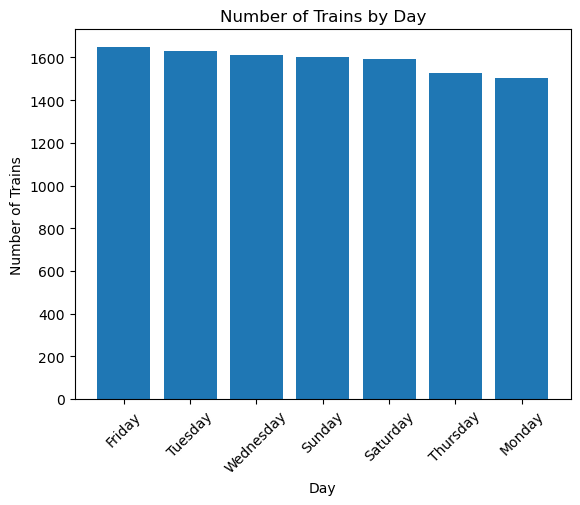

In [22]:
plt.bar(day_counts.index, day_counts.values)

plt.title("Number of Trains by Day")
plt.xlabel("Day")
plt.ylabel("Number of Trains")
plt.xticks(rotation=45)
plt.show()

In [23]:
data["days"].value_counts()

days
Friday       1649
Tuesday      1628
Wednesday    1612
Sunday       1602
Saturday     1593
Thursday     1526
Monday       1503
Name: count, dtype: int64

### Friday has the highest number of trains (1649).

In [24]:
weekday = day_counts[["Monday","Tuesday","Wednesday","Thursday","Friday"]].sum()
weekend = day_counts[["Saturday","Sunday"]].sum()

print(weekday)
print(weekend)

7918
3195


# Task 3.2: Correlation and Insights


Explore if there is any correlation between the number of trains and specific days of the week.
Provide insights and recommendations based on the analysis


## Recommendations:
1. Increase train capacity on Fridays.
2. Monitor weekend demand and add special trains if required.
3. Optimize maintenance schedules on lower-demand days.
4. Focus operational resources on busy stations and routes.

# Insights
1. Train operations are distributed across all days of the week.
2. Friday experiences the highest train frequency.
3. Monday experiences the lowest train frequency.
4. Weekend demand remains significant.

### Level 4: Data Visualization and Reporting

Create visualizations (bar charts, line charts, heatmaps) to represent various aspects of the data (e.g., number of trains per station, day-wise distribution).
Use visualization tools like Matplotlib, Seaborn, or Plot


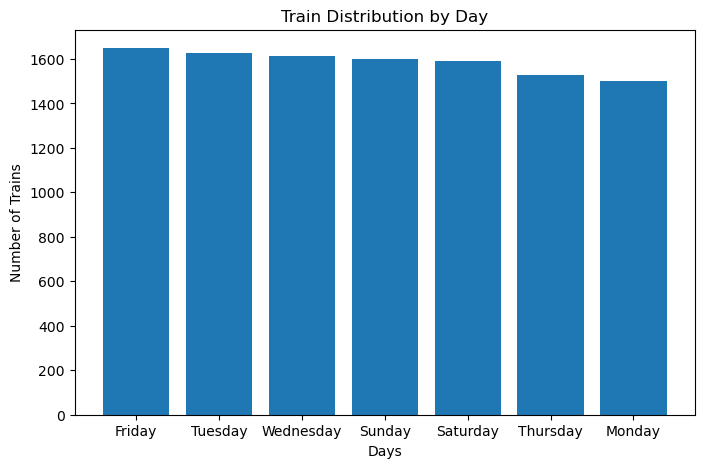

In [44]:
#daywise data
import matplotlib.pyplot as plt

day_counts = data["days"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(day_counts.index, day_counts.values)

plt.title("Train Distribution by Day")
plt.xlabel("Days")
plt.ylabel("Number of Trains")

plt.show()

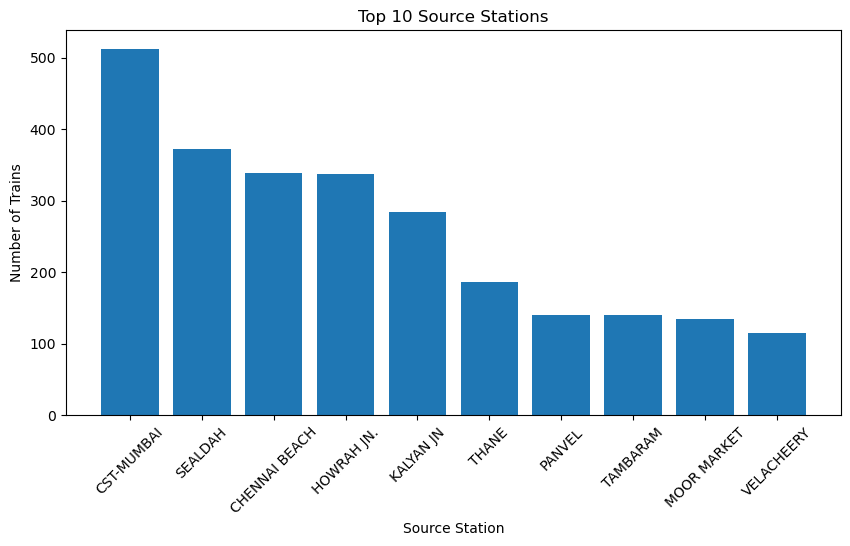

In [46]:
#top 10 source stations
source_count = data["Source_Station_Name"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(source_count.index, source_count.values)

plt.title("Top 10 Source Stations")
plt.xlabel("Source Station")
plt.ylabel("Number of Trains")

plt.xticks(rotation=45)

plt.show()

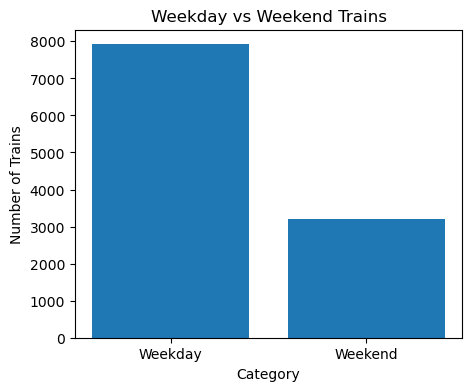

In [48]:
#weekend vs weekday
category_count = data["Category"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(category_count.index, category_count.values)

plt.title("Weekday vs Weekend Trains")
plt.xlabel("Category")
plt.ylabel("Number of Trains")

plt.show()

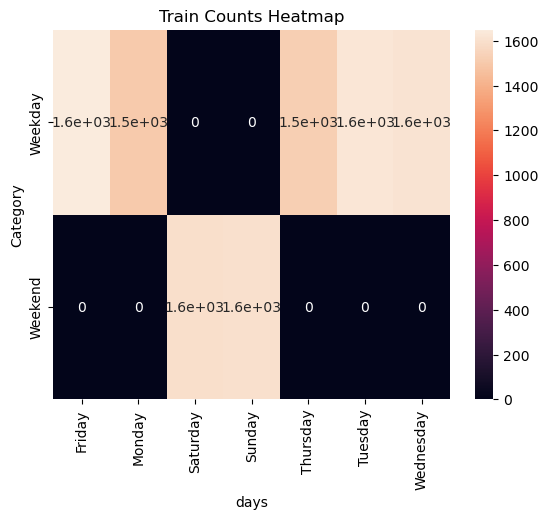

In [50]:
#heatmap
import seaborn as sns

pivot = pd.crosstab(data["Category"], data["days"])

sns.heatmap(pivot, annot=True)

plt.title("Train Counts Heatmap")
plt.show()

# Report

Railway Data Analysis Report
1. Dataset Overview
Total Records: 11113


Unique Source Stations: 921

Unique Destination Stations: 924

3. Data Cleaning
Missing values checked and handled.
Station names standardized to uppercase.
Duplicate day names corrected.


5. Key Findings
Friday has the highest train operations.
Monday has the lowest train operations.
Weekend train activity remains significant.
Certain stations act as major railway hubs.


7. Visualizations
Include:

Day-wise train distribution chart.
Top source stations chart.
Weekday vs Weekend chart.
Heatmap.

5. Insights
Train operations are relatively balanced throughout the week.
Friday experiences the highest demand.
Major stations generate a large share of train traffic.

6. Recommendations
Increase train capacity on busy days.
Optimize scheduling on low-demand days.
Focus operational improvements on major stations.
Monitor weekend demand trends.